# Match the SGA/FLEX and Galaxy Zoo 2 catalogues

This notebook cross-matches galaxies from the SGA/FLEX measurements with the Galaxy Zoo 2 (GZ2) spectroscopic sample. It then checks the quality and sky coverage of the matches and compares a FLEX-derived inclination estimate with the GZ2 weighted edge-on vote fraction.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
import h5py
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table

## Load and combine the SGA/FLEX data

The FLEX measurement table is joined to the SGA galaxy table using `GALAXY` as the common identifier. Suffixes preserve the provenance of fields that occur in both catalogues.

In [2]:
# Load the FLEX measurements and report the catalogue data-model version.
flexdata = pd.read_hdf('FLEX_measurements.h5', key='galaxies')
print('SGA-flex data model version ',h5py.File('FLEX_measurements.h5', 'r')['galaxies'].attrs['data_version'])
# Join the FLEX and SGA measurements by their shared galaxy identifier.
sgadata = pd.read_hdf('SGA_galaxy_data.h5', key='galaxies')
data = pd.merge(flexdata, sgadata, on='GALAXY', suffixes=('_flex', '_sga'))


SGA-flex data model version  1.1.0


### Inspect the combined columns

Listing the merged table's columns verifies that the expected FLEX and SGA measurements are present and that overlapping names carry their catalogue suffixes.

In [3]:
data.keys()

Index(['GALAXY', 'GROUP_RA_flex', 'GROUP_DEC_flex', 'BA_LEDA_flex',
       'PA_LEDA_flex', 'RA_LEDA_flex', 'DEC_LEDA_flex', 'GROUP_NAME_flex',
       'MORPHTYPE_flex', 'D26_flex', 'ASCALE_r', 'ASCALE_g', 'ASCALE_z',
       'BA_flex', 'PA_flex', 'G_MAG_SB26_flex', 'R_MAG_SB26_flex',
       'Z_MAG_SB26_flex', 'G_MAG_SB22_flex', 'R_MAG_SB22_flex',
       'Z_MAG_SB22_flex', 'quality_flag', 'eta_g', 'eta_r', 'eta_z', 'pa_g',
       'pa_r', 'pa_z', 'GROUP_RA_sga', 'GROUP_DEC_sga', 'BA_LEDA_sga',
       'BA_sga', 'PA_sga', 'PA_LEDA_sga', 'RA_LEDA_sga', 'DEC_LEDA_sga',
       'G_MAG_SB26_sga', 'R_MAG_SB26_sga', 'Z_MAG_SB26_sga', 'G_MAG_SB22_sga',
       'R_MAG_SB22_sga', 'Z_MAG_SB22_sga', 'GROUP_NAME_sga', 'MORPHTYPE_sga',
       'D26_sga'],
      dtype='object')

## Load the Galaxy Zoo 2 catalogue

The GZ2 FITS table supplies the comparison coordinates and morphology vote fractions. The coordinate-column check confirms which right-ascension and declination fields are available before matching.

In [4]:
# Load the Galaxy Zoo 2 spectroscopic sample and inspect its sky-coordinate fields.
gz = Table.read('zoo2MainSpecz.fits')
print('Galaxy Zoo columns containing ra/dec:', [col for col in gz.colnames if 'ra' in col.lower() or 'dec' in col.lower()])
ra = gz['ra']
dec = gz['dec']
gz[['ra', 'dec']][:5]

Galaxy Zoo columns containing ra/dec: ['ra', 'dec', 'rastring', 'decstring', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't02_edgeon_a04_yes_fraction', 't02_edgeon_a04_yes_weighted_fraction', 't02_edgeon_a05_no_fraction', 't02_edgeon_a05_no_weighted_fraction', 't03_bar_a06_bar_fraction', 't03_bar_a06_bar_weighted_fraction', 't03_bar_a07_no_bar_fraction', 't03_bar_a07_no_bar_weighted_fraction', 't04_spiral_a08_spiral_count', 't04_spiral_a08_spiral_weight', 't04_spiral_a08_spiral_fraction', 't04_spiral_a08_spiral_weighted_fraction', 't04_spiral_a08_spiral_debiased', 't04_spiral_a08_spiral_flag', 't04_spiral_a09_no_spiral_count', 't04_spiral_a09_no_spiral_weight', 't04_spiral_a09_no_spiral_fract

ra,dec
float32,float32
160.9904,11.70379
192.41083,15.1642065
210.8022,54.348953
185.30342,18.382704
187.36679,8.7499275


## Perform the positional cross-match

Rows without FLEX coordinates are removed, and both catalogues are represented as `SkyCoord` objects in degrees. Each SGA/FLEX galaxy is assigned its nearest GZ2 neighbour. A separation of **3 arcsec or less** defines the accepted sample; this threshold limits chance or incorrect associations while accommodating small coordinate offsets.

In [5]:
# Coordinate matching requires finite RA and Dec values; reset the index for row-wise concatenation below.
data_for_match = data.dropna(subset=['RA_LEDA_flex', 'DEC_LEDA_flex']).reset_index(drop=True).copy()

# Convert both catalogues' coordinates from degrees into spherical sky-coordinate objects.
data_coords = SkyCoord(
    ra=data_for_match['RA_LEDA_flex'].to_numpy() * u.deg,
    dec=data_for_match['DEC_LEDA_flex'].to_numpy() * u.deg,
)
gz_coords = SkyCoord(ra=np.asarray(gz['ra']) * u.deg, dec=np.asarray(gz['dec']) * u.deg)

# For every FLEX/SGA galaxy, find the nearest GZ2 source and its angular separation.
gz_idx, sep2d, _ = data_coords.match_to_catalog_sky(gz_coords)

# Attach the nearest GZ2 row and separation (arcsec) to each FLEX/SGA row.
gz_best = gz[gz_idx].to_pandas().add_prefix('gz_').reset_index(drop=True)
best_match = pd.concat([data_for_match, gz_best], axis=1)
best_match['match_sep_arcsec'] = sep2d.arcsec

# Treat nearest neighbours separated by at most 3 arcsec as reliable cross-matches.
close_match = best_match[best_match['match_sep_arcsec'] <= 3.0].copy()
print(f'Nearest-match table size: {len(best_match)}')
print(f'Matches within 3 arcsec: {len(close_match)}')
best_match[['GALAXY', 'RA_LEDA_flex', 'DEC_LEDA_flex', 'gz_ra', 'gz_dec', 'match_sep_arcsec']].head()

Nearest-match table size: 133942
Matches within 3 arcsec: 78942


,GALAXY,RA_LEDA_flex,DEC_LEDA_flex,gz_ra,gz_dec,match_sep_arcsec
0,PGC1283207,228.377086,5.423202,228.377090,5.423203,0.015827
1,PGC1310416,202.544438,6.934594,202.544495,6.934574,0.216952
2,SDSSJ145059.93+135143.0,222.749787,13.861911,222.749817,13.827516,123.825678
3,PGC1742504,182.088808,25.602276,182.088791,25.602282,0.059419
4,SDSSJ173412.71+572041.6,263.552935,57.344907,263.373199,57.421970,445.649029


### Inspect the matched GZ2 rows

A preview of the selected GZ2 rows provides a quick check that the nearest-neighbour lookup returned the expected catalogue fields.

In [6]:
gz_best.head()

,gz_specobjid,gz_dr8objid,gz_dr7objid,gz_ra,gz_dec,gz_rastring,gz_decstring,gz_sample,gz_gz2class,gz_total_classifications,...,gz_t11_arms_number_a36_more_than_4_fraction,gz_t11_arms_number_a36_more_than_4_weighted_fraction,gz_t11_arms_number_a36_more_than_4_debiased,gz_t11_arms_number_a36_more_than_4_flag,gz_t11_arms_number_a37_cant_tell_count,gz_t11_arms_number_a37_cant_tell_weight,gz_t11_arms_number_a37_cant_tell_fraction,gz_t11_arms_number_a37_cant_tell_weighted_fraction,gz_t11_arms_number_a37_cant_tell_debiased,gz_t11_arms_number_a37_cant_tell_flag
0,2062654748103829504,1237662267537424640,587736546312519985,228.377090,5.423203,b'15:13:30.50',b'+05:25:23.5',b'original ',b'Sb2l ',45,...,0.000,0.000,0.000,0,1,1.0,0.125,0.125,0.116314,0
1,2027820843618297856,1237661971193200640,588017724945006753,202.544495,6.934574,b'13:30:10.68',b'+06:56:04.5',b'original ',b'Sc2l(m) ',30,...,0.000,0.000,0.000,0,0,0.0,0.000,0.000,0.000000,0
2,3096272918619908096,1237668332029083904,587742610804179122,222.749817,13.827516,b'14:50:59.96',b'+13:49:39.1',b'original ',b'Sb?t ',39,...,0.067,0.067,0.067,0,7,7.0,0.467,0.467,0.467000,0
3,2990528216512358400,1237667448339300608,587741727114395866,182.088791,25.602282,b'12:08:21.31',b'+25:36:08.2',b'original ',b'Ser ',40,...,0.000,0.000,0.000,0,0,0.0,0.000,0.000,0.000000,0
4,412094243151046656,1237651311609970944,587725590385066231,263.373199,57.421970,b'17:33:29.57',b'+57:25:19.1',b'original ',b'Ser ',41,...,0.000,0.000,0.000,0,0,0.0,0.000,0.000,0.000000,0


## Inspect match quality and sky coverage

The following diagnostic plots compare accepted and rejected nearest neighbours across the sky. The second plot also shows the complete GZ2 footprint, making it easier to distinguish catalogue-coverage effects from poor positional matches. Right ascension is inverted to follow the usual astronomical convention.

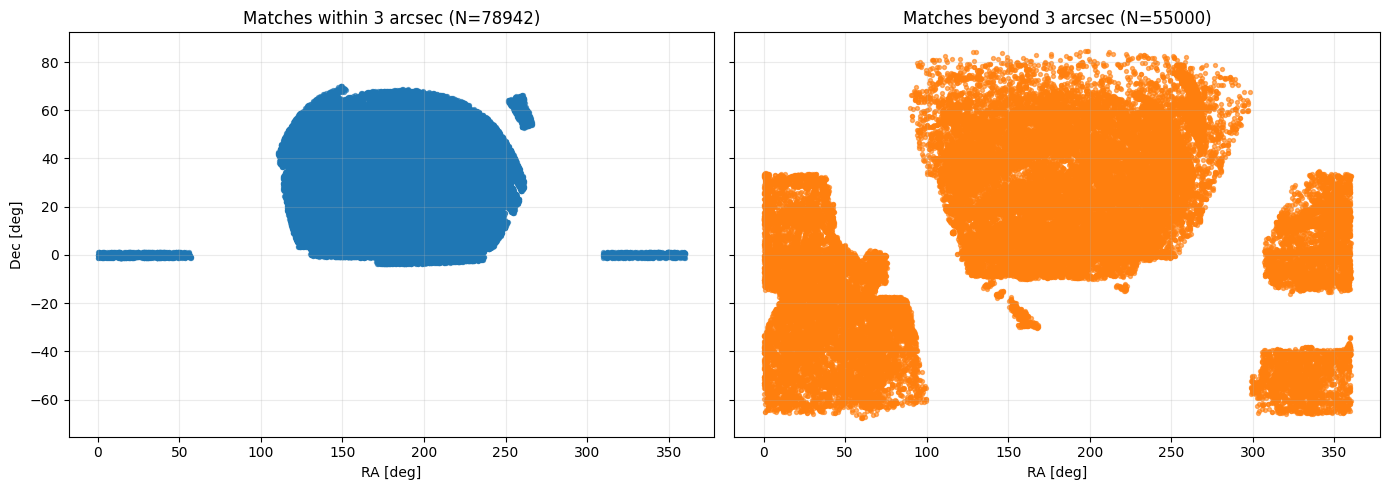

In [7]:
# The complementary sample contains nearest neighbours outside the 3-arcsec acceptance radius.
far_match = best_match[best_match['match_sep_arcsec'] > 3.0].copy()

# Compare the sky distributions of accepted and rejected nearest matches on common axes.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

axes[0].scatter(close_match['RA_LEDA_flex'], close_match['DEC_LEDA_flex'], s=8, alpha=0.6, color='tab:blue')
axes[0].set_title(f'Matches within 3 arcsec (N={len(close_match)})')
axes[0].set_xlabel('RA [deg]')
axes[0].set_ylabel('Dec [deg]')

axes[1].scatter(far_match['RA_LEDA_flex'], far_match['DEC_LEDA_flex'], s=8, alpha=0.6, color='tab:orange')
axes[1].set_title(f'Matches beyond 3 arcsec (N={len(far_match)})')
axes[1].set_xlabel('RA [deg]')

for ax in axes:
    ax.invert_xaxis()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

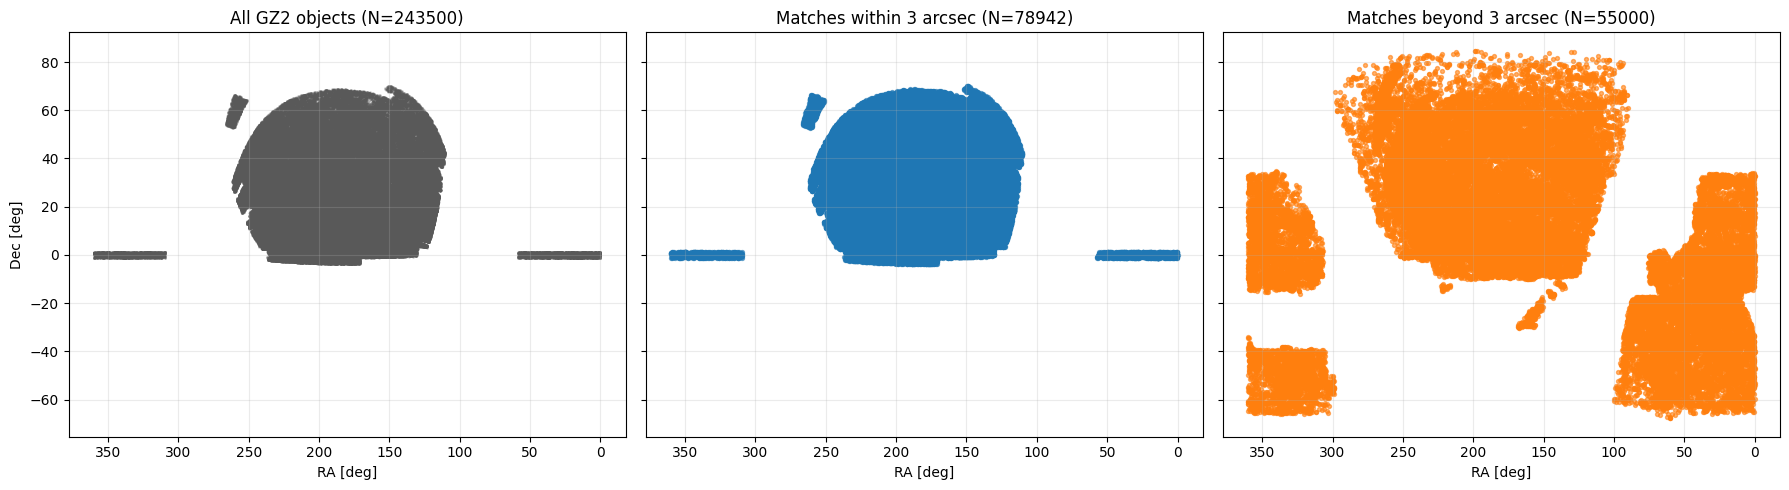

In [8]:
# Recreate the rejected sample so this diagnostic cell remains independently runnable.
far_match = best_match[best_match['match_sep_arcsec'] > 3.0].copy()

# Place the full GZ2 footprint beside accepted and rejected matches for coverage comparison.
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

axes[0].scatter(gz['ra'], gz['dec'], s=1, alpha=0.25, color='0.35', rasterized=True)
axes[0].set_title(f'All GZ2 objects (N={len(gz)})')
axes[0].set_xlabel('RA [deg]')
axes[0].set_ylabel('Dec [deg]')

axes[1].scatter(close_match['RA_LEDA_flex'], close_match['DEC_LEDA_flex'], s=8, alpha=0.6, color='tab:blue')
axes[1].set_title(f'Matches within 3 arcsec (N={len(close_match)})')
axes[1].set_xlabel('RA [deg]')

axes[2].scatter(far_match['RA_LEDA_flex'], far_match['DEC_LEDA_flex'], s=8, alpha=0.6, color='tab:orange')
axes[2].set_title(f'Matches beyond 3 arcsec (N={len(far_match)})')
axes[2].set_xlabel('RA [deg]')

for ax in axes:
    ax.invert_xaxis()
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Estimate inclination from the FLEX shape measurement

The conversion maps the FLEX `eta_r` parameter to an inclination angle and assumes an intrinsic disc thickness of $q_0 = 0.25$. The inverse cosine produces a face-on/edge-on orientation estimate in degrees. This is a model-derived quantity rather than a direct inclination measurement.

In [9]:
def a2_to_inclination(a2, q0=0.25):
    """Convert the FLEX eta_r shape parameter to inclination in degrees.

    q0 is the assumed intrinsic disc thickness. The intermediate expression
    follows the working conversion used in this analysis.
    """
    # Map the measured shape parameter to the cosine-like inclination term.
    cosi = (1 - a2 + q0) ** 2.0
    #incl = np.degrees(np.arccos((1-q0)*cosi))
    # Apply the finite-thickness correction, then convert arccos from radians to degrees.
    incl = np.degrees(np.arccos((1 - q0**2) * cosi))
    return incl

In [10]:
# Calculate a FLEX-derived inclination for every accepted catalogue match.
close_match['inclination'] = a2_to_inclination(close_match['eta_r'])

/opt/homebrew/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Compare inclination with Galaxy Zoo classifications

Only rows with complete FLEX and GZ2 values enter the comparison. The two-dimensional histogram shows how the derived inclination varies with the weighted fraction of GZ2 classifiers who identified the galaxy as edge-on. Logarithmic bin colouring retains visibility across dense and sparse regions. The reported Pearson coefficient separately measures the linear association between `eta_r` and the weighted edge-on fraction.

Close-match rows in comparison: 65486
Pearson correlation: 0.4150189101340131


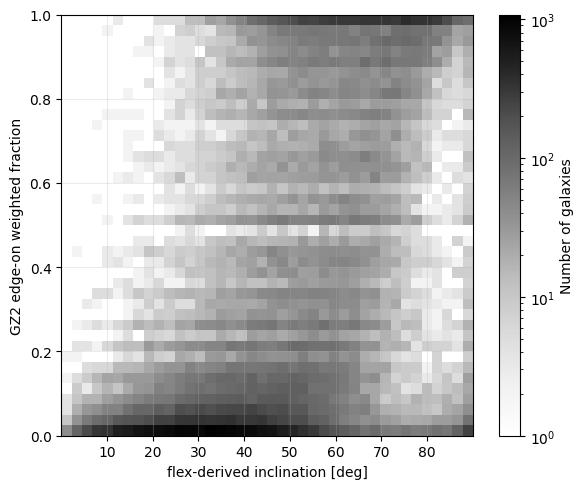

In [11]:
# Retain complete cases so the density plot and correlation use the same galaxy sample.
compare_cols = ['eta_r', 'gz_t02_edgeon_a04_yes_weighted_fraction', 'inclination']
edgeon_vs_eta = close_match[compare_cols].dropna().copy()

# Bin inclination against the GZ2 edge-on vote fraction; logarithmic colour reveals sparse bins.
fig, ax = plt.subplots(figsize=(6, 5))
hist = ax.hist2d(
    edgeon_vs_eta['inclination'],
    edgeon_vs_eta['gz_t02_edgeon_a04_yes_weighted_fraction'],
    bins=40,
    cmap='Greys',
    norm=LogNorm(vmin=1),
)
ax.set_xlabel('flex-derived inclination [deg]')
ax.set_ylabel('GZ2 edge-on weighted fraction')
#ax.set_title('Close-match GZ2 edge-on fraction vs eta_r')
ax.grid(alpha=0.25)
cbar = plt.colorbar(hist[3], ax=ax)
cbar.set_label('Number of galaxies')

print(f'Close-match rows in comparison: {len(edgeon_vs_eta)}')
# Quantify the linear association between eta_r and the weighted GZ2 edge-on vote fraction.
print('Pearson correlation:', edgeon_vs_eta['eta_r'].corr(edgeon_vs_eta['gz_t02_edgeon_a04_yes_weighted_fraction']))
plt.tight_layout()
plt.show()

## Against all SGA

In [18]:
# Load the Galaxy Zoo 2 spectroscopic sample and inspect its sky-coordinate fields.
sga = Table.read('SGA-2020.fits')
print('Galaxy Zoo columns containing ra/dec:', [col for col in gz.colnames if 'ra' in col.lower() or 'dec' in col.lower()])

ra = sga['RA']
dec = sga['DEC']
sga[['RA', 'DEC']][:5]


Galaxy Zoo columns containing ra/dec: ['ra', 'dec', 'rastring', 'decstring', 't01_smooth_or_features_a01_smooth_fraction', 't01_smooth_or_features_a01_smooth_weighted_fraction', 't01_smooth_or_features_a02_features_or_disk_fraction', 't01_smooth_or_features_a02_features_or_disk_weighted_fraction', 't01_smooth_or_features_a03_star_or_artifact_fraction', 't01_smooth_or_features_a03_star_or_artifact_weighted_fraction', 't02_edgeon_a04_yes_fraction', 't02_edgeon_a04_yes_weighted_fraction', 't02_edgeon_a05_no_fraction', 't02_edgeon_a05_no_weighted_fraction', 't03_bar_a06_bar_fraction', 't03_bar_a06_bar_weighted_fraction', 't03_bar_a07_no_bar_fraction', 't03_bar_a07_no_bar_weighted_fraction', 't04_spiral_a08_spiral_count', 't04_spiral_a08_spiral_weight', 't04_spiral_a08_spiral_fraction', 't04_spiral_a08_spiral_weighted_fraction', 't04_spiral_a08_spiral_debiased', 't04_spiral_a08_spiral_flag', 't04_spiral_a09_no_spiral_count', 't04_spiral_a09_no_spiral_weight', 't04_spiral_a09_no_spiral_fract

RA,DEC
float64,float64
228.3770803831908,5.423191398593787
202.5444619671207,6.9346244322326624
222.7497050504303,13.861929561160224
182.08882232629614,25.60226821438983
188.53364923054596,45.595620212931856


In [20]:
# Convert the Astropy table to pandas, remove rows without coordinates, and reset
# the index so its rows align with the matched GZ2 rows during concatenation.
data_for_match = sga.to_pandas().dropna(subset=['RA', 'DEC']).reset_index(drop=True)

# Convert both catalogues' coordinates from degrees into spherical sky-coordinate objects.
data_coords = SkyCoord(
    ra=data_for_match['RA'].to_numpy() * u.deg,
    dec=data_for_match['DEC'].to_numpy() * u.deg,
)
gz_coords = SkyCoord(ra=np.asarray(gz['ra']) * u.deg, dec=np.asarray(gz['dec']) * u.deg)

# For every SGA galaxy, find the nearest GZ2 source and its angular separation.
gz_idx, sep2d, _ = data_coords.match_to_catalog_sky(gz_coords)
    
# Attach the nearest GZ2 row and separation (arcsec) to each FLEX/SGA row.
gz_best = gz[gz_idx].to_pandas().add_prefix('gz_').reset_index(drop=True)
sga_best_match = pd.concat([data_for_match, gz_best], axis=1)
sga_best_match['match_sep_arcsec'] = sep2d.arcsec

# Treat nearest neighbours separated by at most 3 arcsec as reliable cross-matches.
close_match = sga_best_match[sga_best_match['match_sep_arcsec'] <= 3.0].copy()
print(f'Nearest-match table size: {len(sga_best_match)}')
print(f'Matches within 3 arcsec: {len(close_match)}')
sga_best_match[['GALAXY', 'RA', 'DEC', 'gz_ra', 'gz_dec', 'match_sep_arcsec']].head()

Nearest-match table size: 383620
Matches within 3 arcsec: 126871


,GALAXY,RA,DEC,gz_ra,gz_dec,match_sep_arcsec
0,b'PGC1283207',228.377080,5.423191,228.377090,5.423203,0.057013
1,b'PGC1310416',202.544462,6.934624,202.544495,6.934574,0.215804
2,b'SDSSJ145059.93+135143.0',222.749705,13.861930,222.749817,13.827516,123.892711
3,b'PGC1742504',182.088822,25.602268,182.088791,25.602282,0.111811
4,b'2MASXJ12340801+4535444',188.533649,45.595620,188.533615,45.595631,0.096756


In [21]:

sga.colnames

['SGA_ID',
 'SGA_GALAXY',
 'GALAXY',
 'PGC',
 'RA_LEDA',
 'DEC_LEDA',
 'MORPHTYPE',
 'PA_LEDA',
 'D25_LEDA',
 'BA_LEDA',
 'Z_LEDA',
 'SB_D25_LEDA',
 'MAG_LEDA',
 'BYHAND',
 'REF',
 'GROUP_ID',
 'GROUP_NAME',
 'GROUP_MULT',
 'GROUP_PRIMARY',
 'GROUP_RA',
 'GROUP_DEC',
 'GROUP_DIAMETER',
 'BRICKNAME',
 'RA',
 'DEC',
 'D26',
 'D26_REF',
 'PA',
 'BA',
 'RA_MOMENT',
 'DEC_MOMENT',
 'SMA_MOMENT',
 'G_SMA50',
 'R_SMA50',
 'Z_SMA50',
 'SMA_SB22',
 'SMA_SB22.5',
 'SMA_SB23',
 'SMA_SB23.5',
 'SMA_SB24',
 'SMA_SB24.5',
 'SMA_SB25',
 'SMA_SB25.5',
 'SMA_SB26',
 'G_MAG_SB22',
 'R_MAG_SB22',
 'Z_MAG_SB22',
 'G_MAG_SB22.5',
 'R_MAG_SB22.5',
 'Z_MAG_SB22.5',
 'G_MAG_SB23',
 'R_MAG_SB23',
 'Z_MAG_SB23',
 'G_MAG_SB23.5',
 'R_MAG_SB23.5',
 'Z_MAG_SB23.5',
 'G_MAG_SB24',
 'R_MAG_SB24',
 'Z_MAG_SB24',
 'G_MAG_SB24.5',
 'R_MAG_SB24.5',
 'Z_MAG_SB24.5',
 'G_MAG_SB25',
 'R_MAG_SB25',
 'Z_MAG_SB25',
 'G_MAG_SB25.5',
 'R_MAG_SB25.5',
 'Z_MAG_SB25.5',
 'G_MAG_SB26',
 'R_MAG_SB26',
 'Z_MAG_SB26',
 'SMA_SB22_ERR',